In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib

In [4]:
df = pd.read_csv("data/BankChurners.csv")
print(df.shape)
print(df.head(3))

(10127, 23)
   CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0  768805383  Existing Customer            45      M                3   
1  818770008  Existing Customer            49      F                5   
2  713982108  Existing Customer            51      M                3   

  Education_Level Marital_Status Income_Category Card_Category  \
0     High School        Married     $60K - $80K          Blue   
1        Graduate         Single  Less than $40K          Blue   
2        Graduate        Married    $80K - $120K          Blue   

   Months_on_book  ...  Credit_Limit  Total_Revolving_Bal  Avg_Open_To_Buy  \
0              39  ...       12691.0                  777          11914.0   
1              44  ...        8256.0                  864           7392.0   
2              36  ...        3418.0                    0           3418.0   

   Total_Amt_Chng_Q4_Q1  Total_Trans_Amt  Total_Trans_Ct  Total_Ct_Chng_Q4_Q1  \
0                 1.335             

In [5]:
df = df.drop(columns=[
    'CLIENTNUM',
    'Attrition_Flag',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
])

print(df.shape)
print(df.dtypes)

(10127, 19)
Customer_Age                  int64
Gender                          str
Dependent_count               int64
Education_Level                 str
Marital_Status                  str
Income_Category                 str
Card_Category                   str
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object


In [6]:
df_encoded = pd.get_dummies(df, columns=[
    'Gender', 'Education_Level', 'Marital_Status',
    'Income_Category', 'Card_Category'
])

print(df_encoded.shape)
print(df_encoded.head(2))

(10127, 37)
   Customer_Age  Dependent_count  Months_on_book  Total_Relationship_Count  \
0            45                3              39                         5   
1            49                5              44                         6   

   Months_Inactive_12_mon  Contacts_Count_12_mon  Credit_Limit  \
0                       1                      3       12691.0   
1                       1                      2        8256.0   

   Total_Revolving_Bal  Avg_Open_To_Buy  Total_Amt_Chng_Q4_Q1  ...  \
0                  777          11914.0                 1.335  ...   
1                  864           7392.0                 1.541  ...   

   Income_Category_$120K +  Income_Category_$40K - $60K  \
0                    False                        False   
1                    False                        False   

   Income_Category_$60K - $80K  Income_Category_$80K - $120K  \
0                         True                         False   
1                        False       

In [7]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)

print("Shape after scaling:", df_scaled.shape)
print("First row sample:", df_scaled[0][:5].round(2))

Shape after scaling: (10127, 37)
First row sample: [-0.17  0.5   0.38  0.76 -1.33]


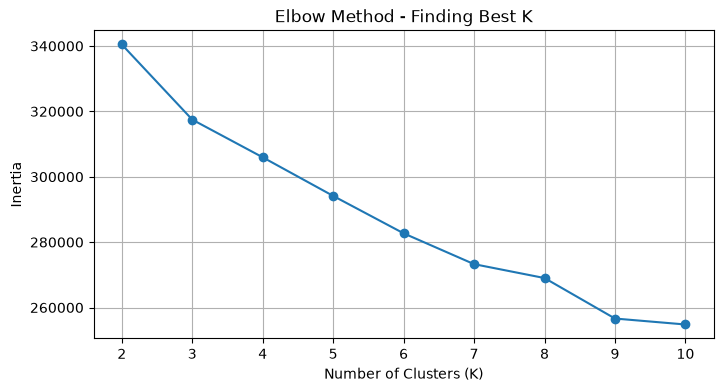

In [8]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method - Finding Best K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [9]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(df_scaled)

df_encoded['Cluster'] = kmeans.labels_
print("Cluster distribution:")
print(df_encoded['Cluster'].value_counts())

Cluster distribution:
Cluster
1    3376
3    3340
0    1675
2    1045
4     691
Name: count, dtype: int64


In [11]:
joblib.dump(kmeans, 'model/kmeans_model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')
print("Models saved!")

Models saved!


In [12]:
cluster_summary = df_encoded.groupby('Cluster').mean().round(2)
print(cluster_summary[['Customer_Age', 'Credit_Limit', 'Total_Trans_Amt', 
                        'Total_Trans_Ct', 'Avg_Utilization_Ratio', 
                        'Months_Inactive_12_mon']].to_string())

         Customer_Age  Credit_Limit  Total_Trans_Amt  Total_Trans_Ct  Avg_Utilization_Ratio  Months_Inactive_12_mon
Cluster                                                                                                            
0               46.11       4590.52          4255.28           64.23                   0.33                    2.31
1               46.36       3296.24          4235.03           65.65                   0.39                    2.37
2               46.34       7990.63          4107.58           65.54                   0.23                    2.39
3               46.52      12669.81          4237.57           61.81                   0.18                    2.33
4               45.69      25949.59          6844.06           76.20                   0.06                    2.28


In [13]:
# Select only 6 key features
features = ['Customer_Age', 'Credit_Limit', 'Total_Trans_Amt', 
            'Total_Trans_Ct', 'Avg_Utilization_Ratio', 
            'Months_Inactive_12_mon']

df_selected = df[features]

# Scale
scaler2 = StandardScaler()
df_scaled2 = scaler2.fit_transform(df_selected)

# Train K-Means
kmeans2 = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans2.fit(df_scaled2)

# Check cluster distribution
df_selected = df_selected.copy()
df_selected['Cluster'] = kmeans2.labels_
print(df_selected.groupby('Cluster')[features].mean().round(2).to_string())

         Customer_Age  Credit_Limit  Total_Trans_Amt  Total_Trans_Ct  Avg_Utilization_Ratio  Months_Inactive_12_mon
Cluster                                                                                                            
0               45.33      14039.11         14050.70          109.11                   0.18                    2.22
1               46.07       2648.36          3829.30           66.52                   0.65                    2.33
2               52.45       6448.93          2471.86           45.82                   0.16                    2.81
3               46.61      27663.47          3827.90           61.10                   0.04                    2.30
4               41.81       6585.28          3983.64           67.41                   0.13                    2.02


In [14]:
joblib.dump(kmeans2, 'model/kmeans_model.pkl')
joblib.dump(scaler2, 'model/scaler.pkl')
print("Models saved!")

Models saved!
